In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN , AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

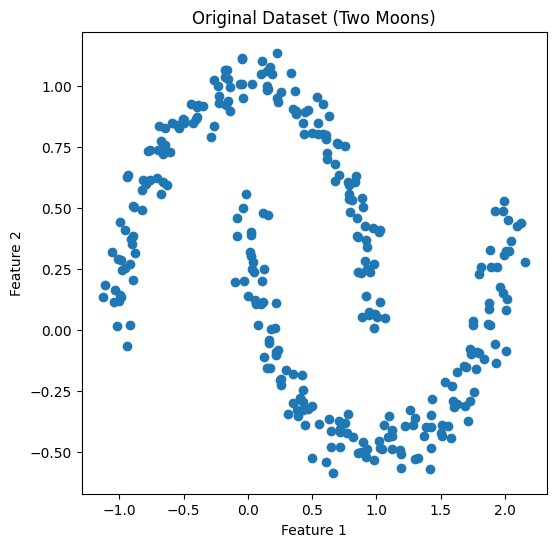

In [8]:
x, y = make_moons(n_samples=300, noise=0.06, random_state=42)

plt.figure(figsize=(6,6))
plt.scatter(x[:,0], x[:,1])
plt.title("Original Dataset (Two Moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

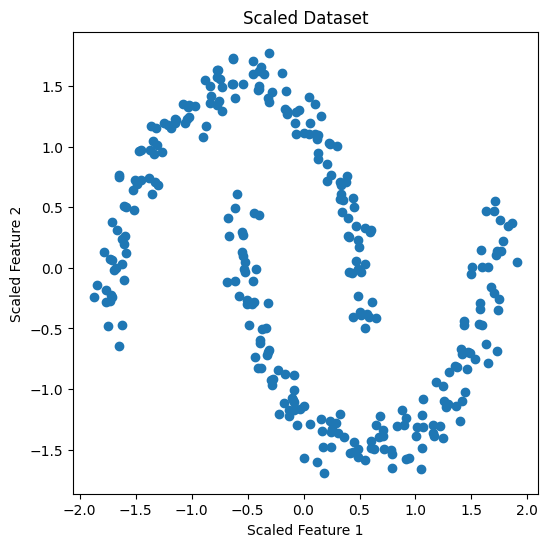

In [14]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

plt.figure(figsize=(6,6))
plt.scatter(x_scaled[:,0], x_scaled[:,1])
plt.title("Scaled Dataset")
plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.show()

In [15]:
# DBSCAN implimentation
dbscan = DBSCAN(eps=0.3 , min_samples=5)

In [16]:
db_labels = dbscan.fit_predict(x_scaled)

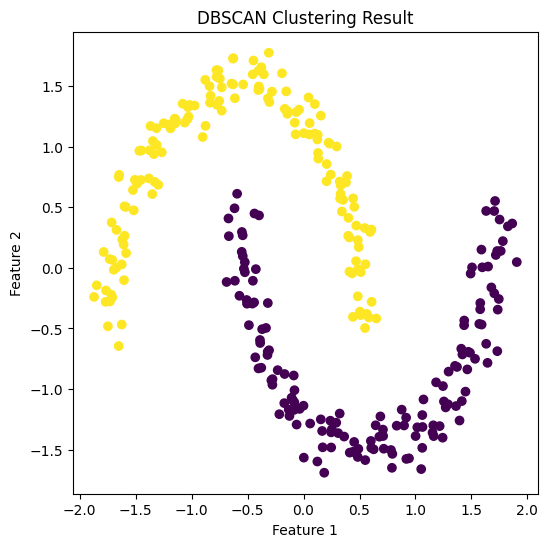

Unique cluster labels: [0 1]


In [18]:
plt.figure(figsize=(6,6))
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=db_labels, cmap='viridis')
plt.title("DBSCAN Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Unique cluster labels:", np.unique(db_labels))

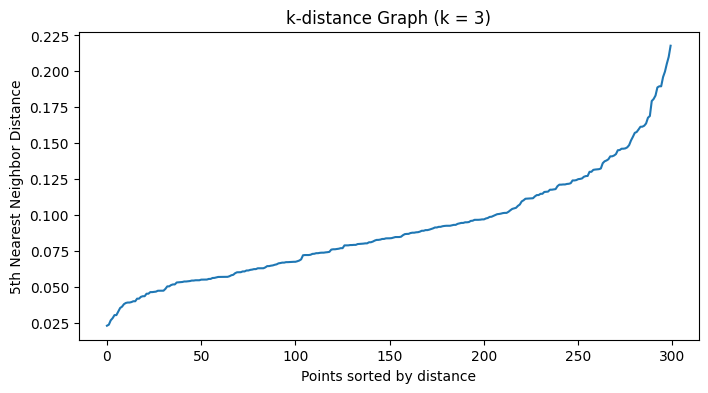

In [19]:
#Choosing eps using k-distance Plot
neighbors = NearestNeighbors(n_neighbors=3)
neighbours_fit = neighbors.fit(x_scaled)
distances, indices = neighbours_fit.kneighbors(x_scaled)

distances = np.sort(distances[:,2])

plt.figure(figsize=(8,4))
plt.plot(distances)
plt.title("k-distance Graph (k = 3)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.show()

In [28]:
#Hierarchical Clustering Implementation
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
hc_labels = hc.fit_predict(x_scaled)

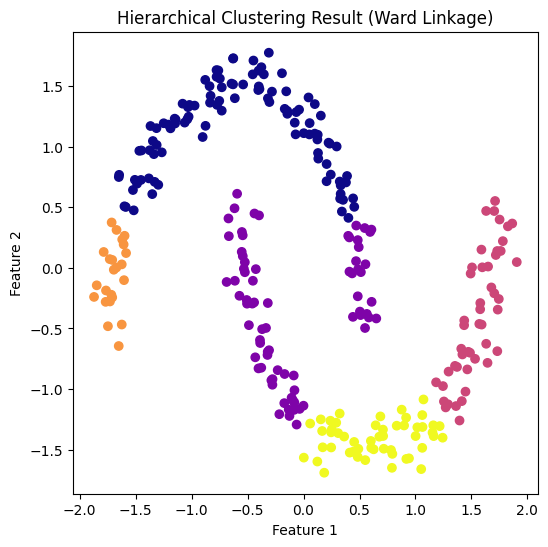

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=hc_labels, cmap='plasma')
plt.title("Hierarchical Clustering Result (Ward Linkage)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

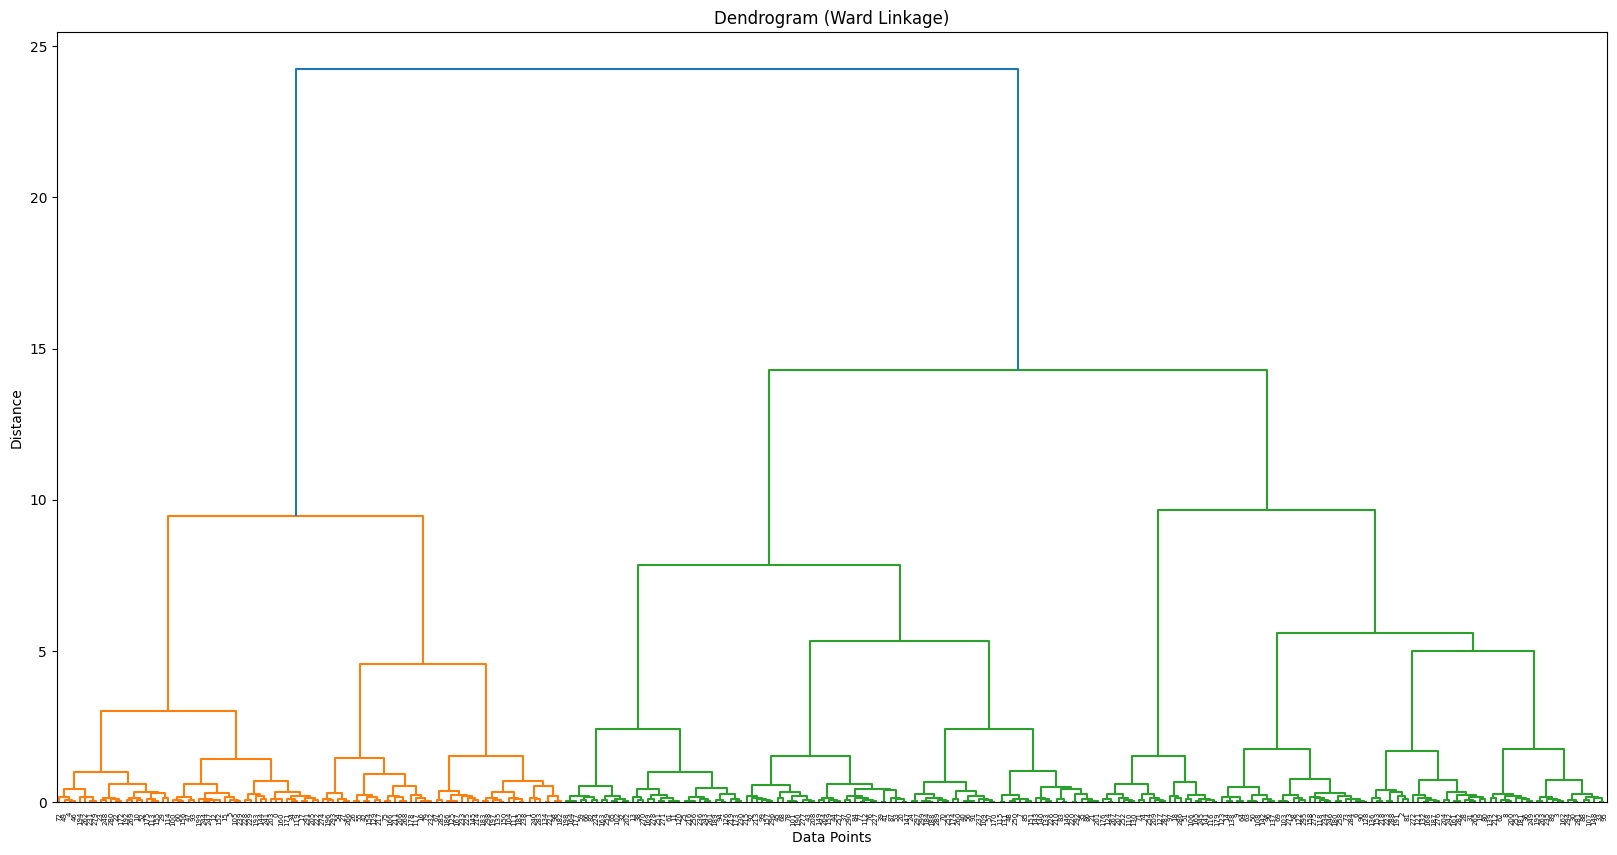

In [30]:
linked = linkage(x_scaled, method='ward')

plt.figure(figsize=(20,10))
dendrogram(linked)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()